In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Spotify_Music_modified.csv')

In [ ]:
df.describe()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
count,39325,39325,39342,39354,39319,39396,39406,39282,39378,39322,...,39381,39344,39318,39401,39357,39355,39394,39336,39376,39330
unique,37662,34560,13746,19197,29024,98,24476,3,994,1593,...,13465,4,1439,4324,4779,1646,1573,21749,7,43
top,error,???,???,???,???,0.0,???,False,???,???,...,error,1.0,error,error,0.0,error,???,error,4.0,gospel
freq,843,859,812,841,828,5109,833,34515,840,809,...,859,23935,821,837,12255,831,831,857,33921,949


In [32]:
# Preview data
df.head(7)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity_category
0,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58.0,214240.0,False,0.688,0.481,6.0,...,1.0,0.1050,0.289,0.000000,0.1890,0.6660,98.017,4.0,acoustic,Medium
1,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74.0,229400.0,False,0.407,0.147,2.0,...,1.0,0.0355,0.857,0.000003,0.0913,0.0765,141.284,3.0,acoustic,High
2,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80.0,242946.0,False,0.703,0.444,11.0,...,1.0,0.0417,0.559,0.000000,0.0973,0.7120,150.960,NaN,acoustic,High
3,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74.0,189613.0,False,0.625,0.414,0.0,...,1.0,0.0369,0.294,0.000000,0.1510,0.6690,130.088,4.0,acoustic,High
4,0X9MxHR1rTkEHDjp95F2OO,Anna Hamilton,Bad Liar,Bad Liar,62.0,248448.0,False,0.691,0.234,3.0,...,1.0,0.0285,0.777,0.000000,0.1200,0.2090,87.103,4.0,acoustic,Medium
5,0BUuuEvNa5T4lMaewyiudB,Jason Mraz,Coffee Moment,93 Million Miles,0.0,216386.0,False,0.572,0.454,3.0,...,1.0,0.0258,0.477,0.000014,0.0974,0.5150,140.182,4.0,acoustic,Low
6,3Hn3LfhrQOaKihdCibJsTs,Jason Mraz,Human - Best Adult Pop Tunes,Unlonely,0.0,231266.0,False,0.796,0.667,5.0,...,0.0,0.0392,0.381,0.000000,0.2210,NaN,97.988,4.0,acoustic,Low


In [31]:
df.tail(7)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity_category
24159,34OSqW5ULWxmCEMjJ1ZgVW,BTS,Love Yourself 轉 'Tear',Anpanman,70.0,232966.0,False,0.813,0.876,1.0,...,0.0,0.0922,0.024,0.000000,0.2870,0.757,98.989,4.0,k-pop,Medium
24160,2kAZP4MIGCitpBHn358pgU,Yuvan Shankar Raja;Bhavatharini;Rizwan,"Meherezylaa (From ""Maanaadu"")","Meherezylaa - From ""Maanaadu""",53.0,259200.0,False,0.734,0.721,9.0,...,0.0,0.0556,NaN,0.000003,0.2560,0.387,100.043,4.0,k-pop,Medium
24161,4t2lPMOLcSRgbI2fZ7iYve,Yuvan Shankar Raja;Priya Hemesh,Take 10: Yuvanshankar Raja,???,52.0,309666.0,False,0.639,0.476,3.0,...,0.0,0.0430,0.138,0.052300,0.0865,0.353,160.093,4.0,k-pop,Medium
24162,7rwZD6MHLSuF2d9h5bnZPz,Alka Yagnik;Kumar Sanu,Bollywood Melody Queen (Alka Yagnik),"Chura Ke Dil Mera (From ""Main Khiladi Tu Anari"")",55.0,474653.0,False,0.613,0.696,NaN,...,error,0.0504,0.136,0.002220,0.0530,0.874,122.056,NaN,k-pop,Medium
24163,59SBaFrtyppqNhyzDpKx3j,Yuvan Shankar Raja;Silambarasan TR;T. Rajendar...,Vallavan (Original Motion Picture Soundtrack),Ammadi Aathadi,53.0,329693.0,False,0.694,0.829,5.0,...,0.0,0.1240,0.520,0.000191,0.0789,0.699,80.018,4.0,k-pop,Medium
24164,4ePEjnKNSifPi60lYnJvoK,Alka Yagnik;Vinod Rathod,Bollywood Melody Queen (Alka Yagnik),"Aisi Deewangi (From ""Deewana"")",54.0,415476.0,False,0.444,0.755,1.0,...,0.0,0.0528,0.512,0.000077,0.0554,0.619,115.051,4.0,k-pop,Medium
24165,4nVUk0Ff9fKbeNQHaYlnyw,Vijay Antony;Sukhwinder Singh;Gayathri,Dishyum (Original Background Score),Kitta Nerungi Vaadi,54.0,257066.0,False,0.798,0.813,9.0,...,0.0,0.2050,NaN,0.000000,0.0846,0.802,89.807,NaN,k-pop,Medium


In [6]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print("Columns:", df.columns)

# Data info
df.info()

Shape: (65349, 21)
Columns: Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65349 entries, 0 to 65348
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        62150 non-null  object
 1   track_id          62206 non-null  object
 2   artists           62072 non-null  object
 3   album_name        62142 non-null  object
 4   track_name        62178 non-null  object
 5   popularity        62285 non-null  object
 6   duration_ms       62244 non-null  object
 7   explicit          62131 non-null  object
 8   danceability      62239 non-null  object
 9   energy            6

In [7]:
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

In [8]:
df.isnull().sum()

,0
track_id,3143
artists,3277
album_name,3207
track_name,3171
popularity,3064
duration_ms,3105
explicit,3218
danceability,3110
energy,3174
key,3144


In [9]:
df = df.dropna()

In [10]:
df.drop_duplicates(inplace=True)

/tmp/ipykernel_1646/3006716147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)


In [11]:
df.reset_index(drop=True, inplace=True)

In [12]:
df.describe()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
count,24166,24166,24166,24166,24166,24166,24166,24166,24166,24166,24166,24166,24166,24166,24166,24166,24166,24166,24166,24166
unique,22064,10455,14429,19578,97,16825,3,955,1351,14,10879,4,1338,4100,4300,1585,1508,15744,7,67
top,???,???,???,???,0.0,???,False,???,???,7.0,error,1.0,error,error,0.0,error,???,error,4.0,???
freq,524,511,536,530,3142,505,21274,514,516,2612,560,14756,496,513,7199,527,529,514,20749,495


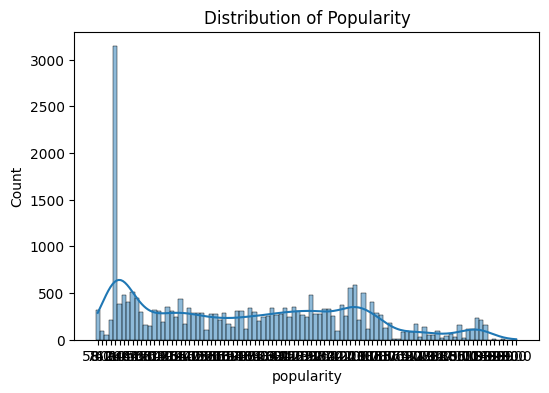

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.histplot(df['popularity'], bins=30, kde=True)
plt.title('Distribution of Popularity')
plt.show()

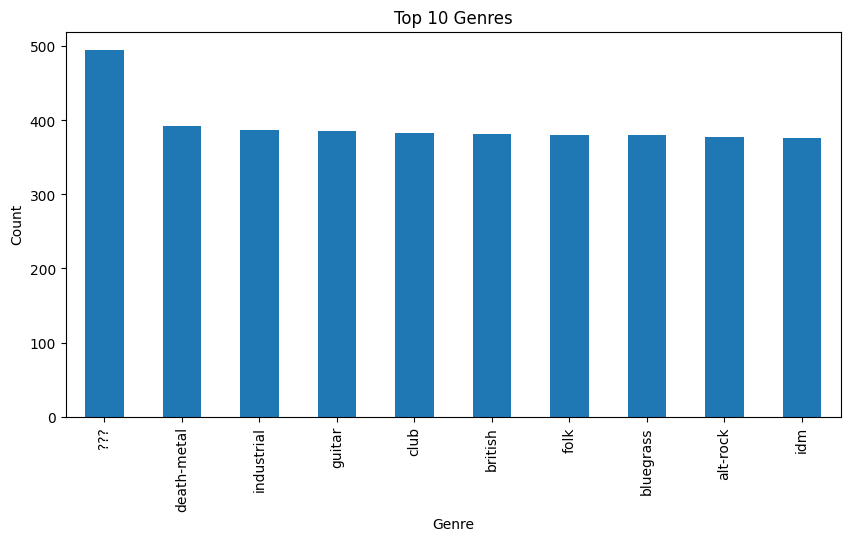

In [15]:
plt.figure(figsize=(10,5))
df['track_genre'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

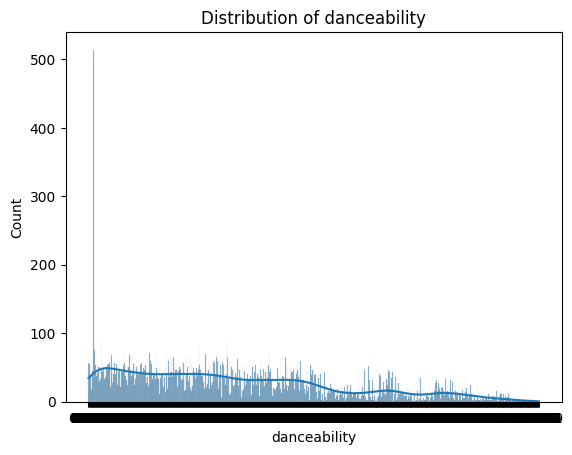

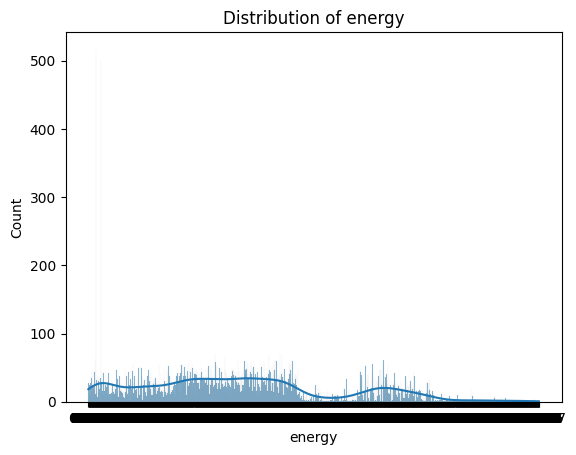

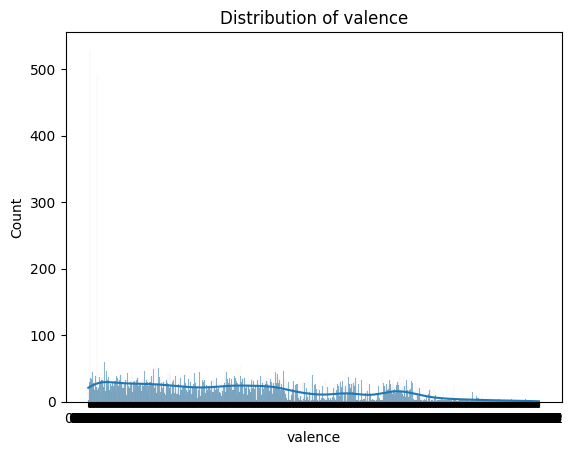

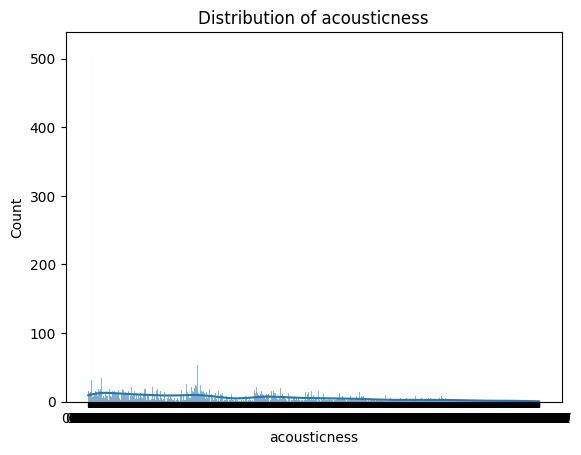

In [16]:
features = ['danceability','energy','valence','acousticness']

for col in features:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [20]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


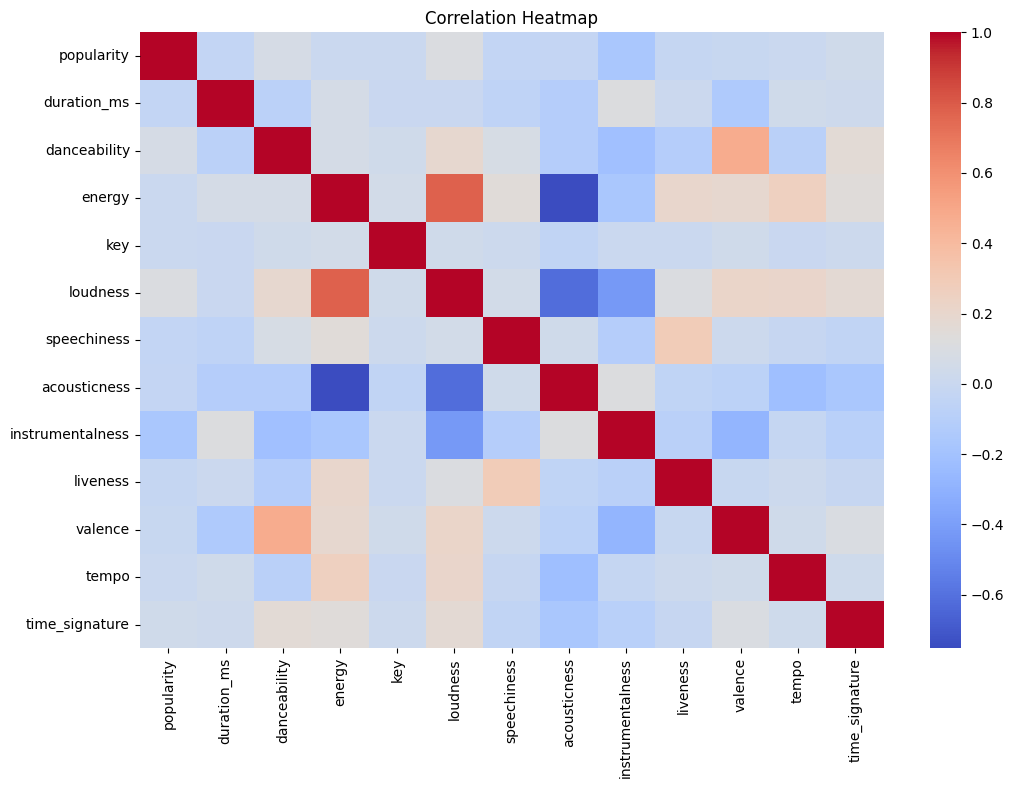

In [22]:
numeric_cols_to_convert = ['popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']

for col in numeric_cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Select only numeric columns and drop any that are entirely NaN after coercion
df_numeric_for_corr = df.select_dtypes(include=np.number).dropna(axis=1, how='all')

if df_numeric_for_corr.empty:
    print("No numeric columns with valid (non-NaN) data found for correlation after conversion.")
else:
    plt.figure(figsize=(12,8))
    corr = df_numeric_for_corr.corr()
    sns.heatmap(corr, cmap='coolwarm', annot=False)
    plt.title('Correlation Heatmap')
    plt.show()

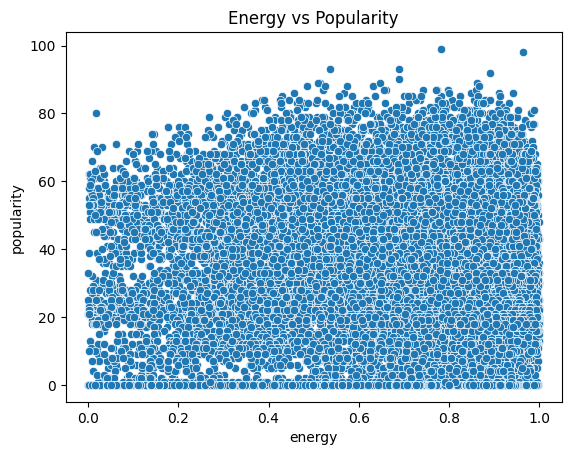

In [23]:
plt.figure()
sns.scatterplot(x='energy', y='popularity', data=df)
plt.title('Energy vs Popularity')
plt.show()

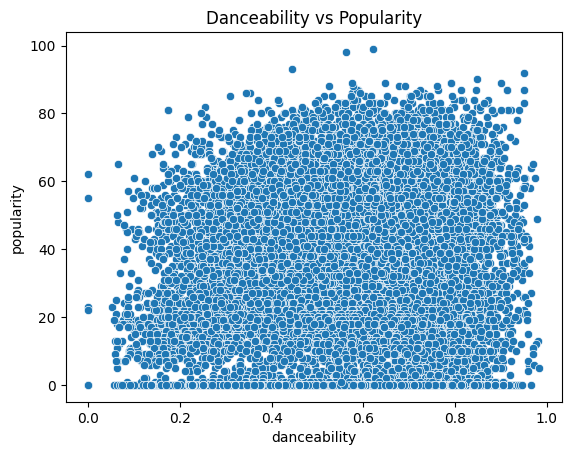

In [24]:
plt.figure()
sns.scatterplot(x='danceability', y='popularity', data=df)
plt.title('Danceability vs Popularity')
plt.show()

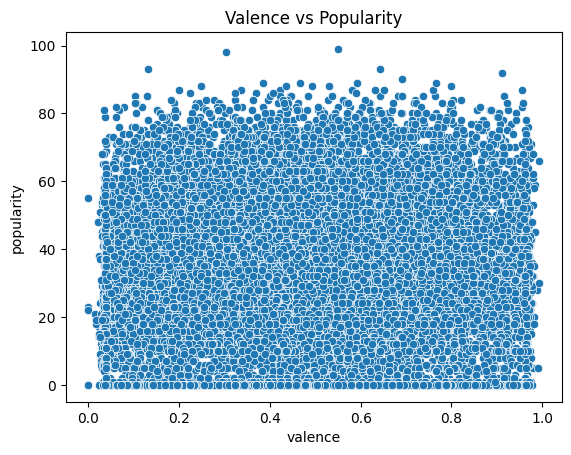

In [25]:
plt.figure()
sns.scatterplot(x='valence', y='popularity', data=df)
plt.title('Valence vs Popularity')
plt.show()

In [29]:
df['popularity_category'] = df['popularity'].apply(
    lambda x: 'High' if x > 70 else ('Medium' if x > 40 else 'Low')
)

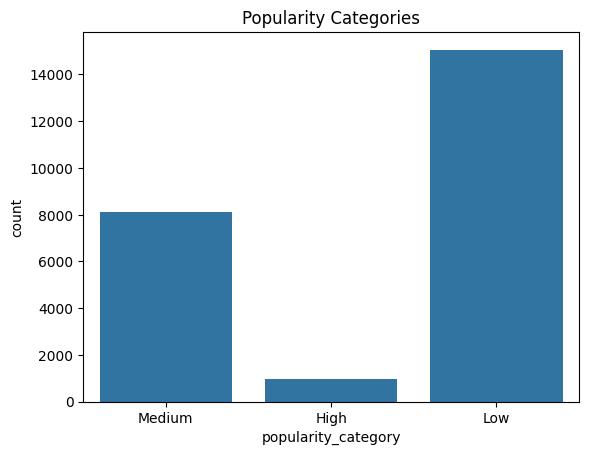

In [30]:
sns.countplot(x='popularity_category', data=df)
plt.title('Popularity Categories')
plt.show()